<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif;">

<h1 style="color: #004080; border-bottom: 3px solid #004080; padding-bottom: 10px; font-weight: 800; margin-top: 0;">
    Aquaverse Short Course Part I: Mixture Density Networks (MDNs)
</h1>

<p style="font-size: 1.15em; line-height: 1.7; color: #222222;">
    This notebook introduces the <b>Mixture Density Network (MDN)</b> framework. MDNs are a powerful variant of neural networks that estimate outputs as a <b>probability distribution</b> rather than a single point value. This is a vital distinction for solving <b>inverse physical problems</b>—where a single observation may correspond to multiple physical states—and allows the model to provide a robust estimate of <b>predictive uncertainty</b>.
</p>

<p style="font-size: 1.15em; line-height: 1.7; color: #222222;">
    Selected WQ products generated using our MDN pipelines are available for visualization and download via NASA's <a href="https://ladsweb.modaps.eosdis.nasa.gov/stream/" target="_blank" style="color:#0056b3;text-decoration:underline;font-weight:bold;"> Satellite-based Tool for Rapid Evaluation of Aquatic environMents (STREAM)</a> website.
</p>



<h3 style="color: #004080; margin-top: 25px;"><b>Course Objectives</b></h3>
<ul style="line-height: 1.9; color: #1a1a1a; list-style-type: none; padding-left: 0;">
    <li><span style="color: #d35400;">■</span> <b>01. Environment Setup:</b> Import the SSAI Freshwater Sensing Group's MDN distribution.</li>
    <li><span style="color: #d35400;">■</span> <b>02. Data Acquisition:</b> Download the <a href="https://doi.pangaea.de/10.1594/PANGAEA.948492" target="_blank" style="color: #0056b3; text-decoration: underline; font-weight: bold;">GLORIA dataset</a>—a collection of collocated <i>in situ</i> Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>) and Water Quality (WQ) variables.</li>
    <li><span style="color: #d35400;">■</span> <b>03. Architecture:</b> Understand MDN structures and output parameterization.</li>
    <li><span style="color: #d35400;">■</span> <b>04. Biogeochemical Prediction:</b> Extract WQ parameters from Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>).</li>
    <li><span style="color: #d35400;">■</span> <b>05. Uncertainty Analysis:</b> Visualize MDN outputs, explain how point estimates are derived, and demonstrate how to quantify predictive uncertainty.</li>
</ul>

<div style="background-color: #fcf8e3; color: #8a6d3b; padding: 15px; border: 1px solid #faebcc; border-left: 6px solid #8a6d3b; margin: 20px 0; font-weight: 500;">
    <strong>Requirement:</strong> Please run all sections in sequential order to maintain data integrity and variable definitions.
</div>

<hr style="border: 0; border-top: 2px solid #eee;">

<div style="margin-bottom: 20px;">
    <strong style="color: #004080; font-size: 1.1em;">Freshwater Sensing Group</strong><br>
    <span style="color: #444;">Science Systems and Applications, Inc. / NASA Goddard Space Flight Center</span><br>
    <span style="color: #666;">August 2026</span>
</div>

<h4 style="color: #004080; margin-bottom: 10px;">Technical Contacts</h4>
<table style="width: 100%; border-collapse: collapse; border: 1px solid #ddd;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Domain</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Section Lead</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Email</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">BPs & IOP Products</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Ryan E. O'Shea</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:ryan.oshea@ssaihq.com" style="color: #0056b3; font-weight: bold;">ryan.oshea@ssaihq.com</a></td>
        </tr>
        <tr style="background-color: #fafafa;">
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Uncertainties</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Arun Saranathan</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:arun.saranathan@ssaihq.com" style="color: #0056b3; font-weight: bold;">arun.saranathan@ssaihq.com</a></td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Atmospheric Correction</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Akash Ashapure</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:akash.ashapure@ssaihq.com" style="color: #0056b3; font-weight: bold;">akash.ashapure@ssaihq.com</a></td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Stream Website</td>
            <td style="padding: 10px; border: 1px solid #ddd;">William Wainwright</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:william.wainwright@ssaihq.com" style="color: #0056b3; font-weight: bold;">william.wainwright@ssaihq.com</a></td>
        </tr>
    </tbody>
</table>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 1: MDN Package Import and Verification
</h2>

<p style="font-size: 1.15em; color: #222222;">
    A <b>TensorFlow-based</b> implementation of Mixture Density Networks is provided via the custom <code>MDN</code> package included with this course. To begin, we must initialize the environment by importing the specific modules required for model architecture construction, weight loading, and spectral preprocessing.
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    The import process verifies that your local environment has the necessary <b>TensorFlow</b> and <b>TensorFlow Probability</b> dependencies configured correctly to handle the stochastic nature of the MDN output layer.
</div>

<p style="font-size: 1.1em; color: #222222;">
    Please run the following code cell to load the core functions and verify that the package is accessible within your current Python kernel.
</p>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 1.1
</div>

</div>

In [1]:
# Import the base python packages needed for this notebook
import numpy                                                          as np
import scipy
import os
import subprocess
from   pathlib                    import Path
from   urllib.request             import urlretrieve
import zipfile
import matplotlib                                                     as mpl
import matplotlib.pyplot                                              as plt
import matplotlib.patches                                             as patches
from   matplotlib                 import ticker
from   matplotlib.colors          import LogNorm
import sys
sys.path.append("C:\\Users\\asaranat\\OneDrive - NASA\\Code\\MDN-STREAM\\")

# Supressing tensorflow based warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('tensorflow_probability').setLevel(logging.ERROR)

# Import some specific functions and packages from MDN implementation
from   MDN                        import get_sensor_bands, get_tile_data
from   MDN                        import current_support 
from   MDN                        import get_gloria_trainTestData, get_args
from   MDN                        import get_mdn_preds, create_scatterplots_trueVsPred, performance
from   MDN                        import OC, resample_Rrs 

[compat_patch] NumPy version: 2.3.3
[compat_patch] Applied NumPy _randomstate_ctor patch.
[compat_patch] TensorFlow version: 2.20.0
[compat_patch] Applied TensorFlow TrackableReference patch (tracking.base).
[compat_patch] NumPy version: 2.3.3
[compat_patch] TensorFlow version: 2.20.0
Modified RC Params: dict_keys(['backend'])


In [2]:
# Set display parameters via MATPLOTLIB for this notebook
plt.rcParams.update({"text.usetex": False,})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['mathtext.default'] = 'regular'
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
mrkSize = 15
ASPECT = "auto"
cmap = "jet"

mpl.rcParams['xtick.labelsize'] = SMALL_SIZE
mpl.rcParams['ytick.labelsize'] = SMALL_SIZE

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 2: Download and Process the GLORIA Dataset
</h2>

<p style="font-size: 1.15em; color: #222222;">
    To evaluate the MDN's operation and performance, we will utilize the 
    <a href="https://doi.pangaea.de/10.1594/PANGAEA.948492" target="_blank" style="color: #0056b3; text-decoration: underline; font-weight: bold;">
        GLObal Reflectance community dataset for Imaging and optical sensing of Aquatic environments (GLORIA)
    </a>.
</p>

<p style="font-size: 1.1em; color: #222222;">
    GLORIA is a comprehensive, globally distributed <i>in situ</i> dataset specifically designed for the training and the validation of aquatic remote sensing algorithms. It provides the collocated pairs of hyperspectral/multispectral Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>) and corresponding water quality measurements required to test the predictive capabilities of the MDN.
</p>

<div style="background-color: #eafaf1; color: #145a32; padding: 15px; border: 1px solid #d4efdf; border-left: 6px solid #27ae60; margin: 20px 0;">
    <strong style="font-size: 1.1em;">Action Required:</strong> 
    The following cells will automate the download from the PANGAEA repository and perform the necessary spectral subsetting to match the sensor dimensions expected by the MDN architecture.
</div>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 1.2
</div>

</div>

In [3]:
# Define the path where the dataset will be stored
zip_path = os.path.join("data", "GLORIA-2022.zip")

# Check if the file exists; if not, create the directory and download
if not os.path.exists(zip_path):
    os.makedirs("data", exist_ok=True)
    print(f"Downloading GLORIA dataset to {zip_path}...")
    subprocess.run([
        "curl",
        "-L",
        "-o", zip_path,
        "https://download.pangaea.de/dataset/948492/files/GLORIA-2022.zip"
    ], check=True)
    print("Download complete.")
else:
    print("Dataset already exists locally.")

Download complete.


In [4]:
# Set up the paths for the GLORIA dataset
zip_file_path = 'data/GLORIA-2022.zip'
extract_to_dir = 'data/'

# Ensure the extraction directory exists
os.makedirs(extract_to_dir, exist_ok=True)

print(f"Extracting {zip_file_path}...")

# Unzip the downloaded dataset
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_dir)
    print(f'Successfully extracted files to: {extract_to_dir}')

Extracting data/GLORIA-2022.zip...
Successfully extracted files to: data/


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.15em; color: #222222; margin-top: 0;">
    The GLORIA dataset contains hyperspectral <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> samples spanning 350–800 nm, interpolated to a 1 nm resolution. To ensure the MDN models are compatible with specific Ocean Color (OC) satellite sensors, we must perform <b>spectral resampling</b>.
</p>



<p style="font-size: 1.1em; color: #222222;">
    This process utilizes the instrument's <b>Relative Spectral Response (RsR)</b> function to weight the hyperspectral data according to the sensitivity of each satellite band. Following resampling, the data is partitioned into two distinct subsets:
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0;">
    <strong style="font-size: 1.1em;">Methodology Note:</strong> 
    By resampling to the RsR of specific missions (e.g., PACE, Landsat-8, Sentinel-3), we ensure that the MDN can be operationally applied to real-world satellite imagery. The full list of supported sensors can be seen below.
</div>

</div>

In [9]:
# Set the GLORIA folder and extract the data
gloria_folder = Path().cwd() / 'data/GLORIA_2022/'

assert gloria_folder.is_dir(), f"No folder found art {gloria_folder}"

# Get the GLORIA data at the resolution of the OLCI sensor
x_data, y_data, gid_data = get_gloria_trainTestData(sensor='OLCI', out_var=["chl"],
                                                    save_flag=False, load_exists=False,rand_seed=42,
                                                    rem_flagged=True, gloria_folder=gloria_folder,
                                                    flag_name='GLORIA_qc_flags.csv', rrs_name='GLORIA_Rrs.csv',
                                                    bg_name='GLORIA_meta_and_lab.csv', gloria_only=True,
                                                    train_mode=False)

# Get the wavelengths available for this sensor
wvl_bands = get_sensor_bands("OLCI")

Bands with responses outside of range [350, 899]: 
 [np.float64(900.0), np.float64(940.0), np.float64(1020.0)]

Creating data for bands
 [np.float64(400.0), np.float64(412.5), np.float64(442.5), np.float64(490.0), np.float64(510.0), np.float64(560.0), np.float64(620.0), np.float64(665.0), np.float64(673.75), np.float64(681.25), np.float64(708.75), np.float64(753.75), np.float64(761.25), np.float64(764.375), np.float64(767.5), np.float64(778.75), np.float64(865.0), np.float64(885.0)]


100%|██████████| 7572/7572 [00:05<00:00, 1280.17it/s]


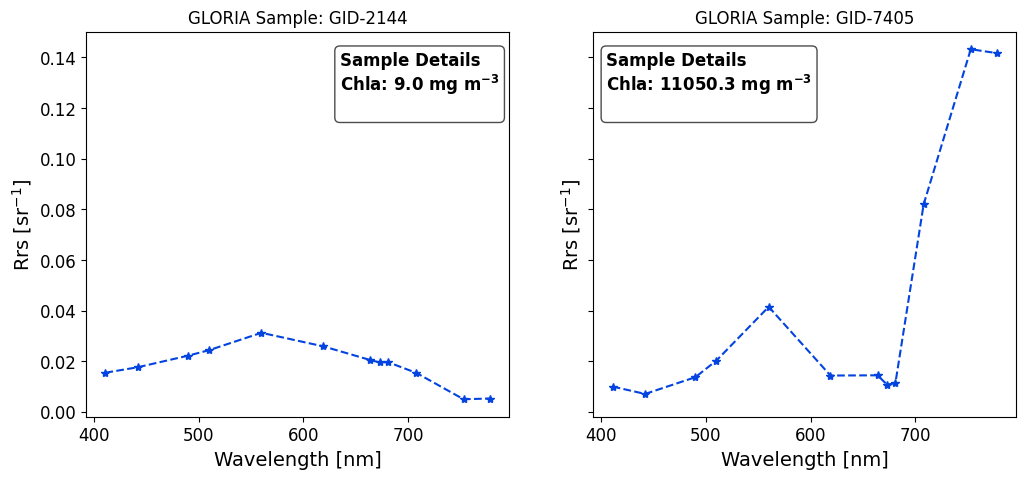

In [15]:
# Visualize a sample from the Gloria data
idx_1 = np.where(gid_data == "GID_2144")[0]    #np.random.choice(x_data.shape[0])
idx_2 = np.where(gid_data == "GID_7405")[0]
fig1, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5), sharey=True)
ax[0].plot(wvl_bands, np.squeeze(x_data[idx_1, :]), linestyle="--", marker="*", color="xkcd:blue")
ax[0].set_title("GLORIA Sample: " + gid_data[idx_1][0].replace('_', '-'));
ax[0].set_xlabel('Wavelength [nm]');
ax[0].set_ylabel(r'Rrs [$sr^{-1}$]');

label= []
for item in y_data[idx_1, :][0]:
    if np.isnan(item):
        label += ['N/A']
    else:
        label+= [f'{item:.1f}']

if plt.rcParams['text.usetex']:
    textstr1 = (r"\underline{\textbf{Sample Details}}" + '\n' + r"\textbf{Chla}:" + f' {label[0]} ' + r"$mg~m^{-3}$" + '\n')
else:
    textstr1 = (r"Sample Details" + '\n' + r"Chla:" + f' {label[0]} ' + r"$mg~m^{-3}$" + '\n')

    #+ r"\textbf{TSS:}" + f'           {label[1]} ' + r"$mg~m^{-3}$" + '\n'  + r"\textbf{acdom:}" + f'    {label[2]} ' + r"$m^{-1}$ " + '\n');
props = dict(boxstyle='round', facecolor='white', alpha=0.7)
ax[0].text(0.6, 0.95, textstr1, transform=ax[0].transAxes, fontsize=SMALL_SIZE*1, weight="bold", verticalalignment='top', bbox=props);

ax[1].plot(wvl_bands, np.squeeze(x_data[idx_2, :]), linestyle="--", marker="*", color="xkcd:blue")
ax[1].set_title("GLORIA Sample: " + gid_data[idx_2][0].replace('_', '-'));
ax[1].set_xlabel('Wavelength [nm]');
ax[1].set_ylabel(r'Rrs [$sr^{-1}$]');

label= []
for item in y_data[idx_2, :][0]:
    if np.isnan(item):
        label += ['N/A']
    else:
        label+= [f'{item:.1f}']
        
if plt.rcParams['text.usetex']:
    textstr1 = (r"\underline{\textbf{Sample Details}}" + '\n' + r"\textbf{Chla}:" + f' {label[0]} ' + r"$mg~m^{-3}$" + '\n')
else:
    textstr1 = (r"Sample Details" + '\n' + r"Chla:" + f' {label[0]} ' + r"$mg~m^{-3}$" + '\n')

    #+ r"\textbf{TSS:}" + f'           {label[1]} ' + r"$mg~m^{-3}$" + '\n'  + r"\textbf{acdom:}" + f'    {label[2]} ' + r"$m^{-1}$ " + '\n');
props = dict(boxstyle='round', facecolor='white', alpha=0.7)
ax[1].text(0.03, 0.95, textstr1, transform=ax[1].transAxes, fontsize=SMALL_SIZE*1, weight="bold", verticalalignment='top', bbox=props);

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.15em; color: #222222; margin-top: 0;">
    Now that we have GLORIA <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> and are able resample them according to the Rrs of a specific instrument for e.g. <b>Sentinel-3 OLCI</b> (Ocean and Land Colour Instrument) resolution, we are ready to proceed with model inference.
</p>


<p style="font-size: 1.1em; color: #222222;">
    In the following steps, we will use the trained MDN to generate predictions for every spectrum in the GLORIA database. Our primary focus will be <b>evaluating the MDN's performance</b> using the independent test dataset—benchmarking how well the predicted probability distributions align with the <i>in situ</i> observations.
</p>

<div style="background-color: #f4eefd; color: #5b2c91; padding: 15px; border: 1px solid #e1d5f5; border-left: 6px solid #5b2c91; margin: 20px 0;">
    <strong style="font-size: 1.1em;">Next Step:</strong> 
    We will feed the resampled reflectance spectra into the MDN architecture to retrieve the mixture parameters (means, variances, and weights) and derive the final biogeochemical estimates and compare them to the true values.
</div>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 3: A Brief Introduction to Inverse Modeling and MDNs
</h2>

<p style="font-size: 1.1em; color: #222222;">
    Classical ML-based regression algorithms typically assume that the causal factors affecting a system are known, and the model attempts to predict a <b>dependent variable</b>. In aquatic optics, Biogeochemical Parameters (BPs) and Inherent Optical Properties (IOPs) are the causal factors that dictate the color of the water column. However, Ocean Color (OC) sensors measure the result of these factors in the form of Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>).
</p>

<p style="font-size: 1.1em; color: #222222;">
    Inferring BPs and IOPs from <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> is known as an <b>Inverse Problem</b> (Mobley et al., 1994). These systems are often "Many-to-One"—meaning multiple combinations of water constituents can produce the same spectral signature. This results in a <b>multi-modal</b> output distribution. Because classical ML models assume a single, unimodal output for every input, they are often ill-suited for the ambiguities inherent in inverse modeling.
</p>



<p style="font-size: 1.1em; color: #222222;">
    <b>Mixture Density Networks (MDNs)</b> (Bishop, 1994) address this by predicting a <b>probability distribution</b> rather than a single point estimate. Specifically, MDNs output a <b>Mixture of Gaussians (MoG)</b>, which can represent arbitrarily complex distributions. Recent literature demonstrates that MDN-generated estimates are particularly robust in optically complex eutrophic inland and coastal waters, frequently outperforming classical ML models and operational band-ratio algorithms (Smith et al., 2020; Pahlevan et al., 2021; O'Shea et al., 2023).
</p>

<h4 style="color: #004080; margin-top: 20px;"><b>The Processing Pipeline</b></h4>
<p style="font-size: 1.05em; color: #222222;">
    As shown in <b>Fig. 1</b>, the pipeline follows a structured path:
    <ul style="padding-left: 20px;">
        <li><b>Feature Engineering:</b> Proven Band Ratios (BRs) and Line Heights (LHs) are calculated and appended to the input <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>.</li>
        <li><b>Normalization & Processing:</b> Inputs are normalized and passed through a deep neural network.</li>
        <li><b>Mixture Output:</b> The final layer generates parameters (mean, standard deviation, and mixing coefficient) for multiple Gaussian components.</li>
        <li><b>Product Retrieval:</b> The final estimate is derived via a combination function—typically selecting the mean of the most probable Gaussian component.</li>
    </ul>
</p>

<center>
<div style="border: 2px solid #2c3e50; padding: 15px; border-radius: 8px; width: fit-content; background-color: #f9f9f9; margin-top: 20px;">
    <img src="images/oshea_mdn_pipeline.jpg" alt="MDN processing pipeline" width="800" style="display: block; margin-bottom: 10px; border: 1px solid #ddd;" />
    <div style="text-align: center; font-family: 'Segoe UI', Arial, sans-serif; font-size: 14px; color: #555; font-weight: 600;">
        Fig. 1: MDN pipeline for estimating BPs/IOPs from <span style="font-family: 'Times New Roman', serif; font-style: italic;">R<sub>rs</sub></span> (adapted from O'Shea et al., 2023).
    </div>
</div>
</center>

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 1.3
</div>

</div>